In [ ]:
from opty import Problem, create_objective_function, parse_free
import sympy as sp
import numpy as np
import scipy as sc
import time as tm
import pickle
import sympy.physics.mechanics as me
import sys
sys.path.insert(0, "..")
from importlib import reload
import matplotlib.pyplot as plt
import equations as eq
reload (eq);
import trajectory_lib as tr
reload (tr);

participant = '1LU'
motion_list  =  ['shelf']
GH_seq = 'YZY'
include_q_clavicula_init = True

motion_folder = motion_list[0]
motion_name = motion_list[0]

OS_struct = sc.io.loadmat('../Motions/'+participant+'/OS_model.mat')
# optim_params_struct = sc.io.loadmat('../Motions/'+participant+'/'+motion_name+'/params_optimized_'+motion_name+'.mat')
include_activation_dynamics = False

act_w = 1
vel_w = 0.1

MM,FO,q,u,u0,fr,frstar,kinematical,xdot,holonomic,first_elips_scale,elips_trans = eq.create_eoms_u0state(OS_struct,derive = 'numeric',gen_matlab_functions = 0)
TE,activations,TE_conoid, fmax_init, fmax_range, lceopt_init, lceopt_range, mus_groups = eq.polynomials_quat(OS_struct,q,u,optim_params = None, derive = 'numeric')

In [20]:
# # params_init = {**fmax_init, **lceopt_init}
# params_init = fmax_init
# # params_range = {**fmax_range, **lceopt_range}
# params_range = fmax_range
# myKeys = list(params_init.keys())
# myKeys.sort()

# # Sorted Dictionary
# sd = {i: params_init[i] for i in myKeys}
# sorted_params_init = np.array([*sd.values()])
# num_params = len(sorted_params_init)
# print(sd)

In [21]:
# reload(eq)
# eq.optimize_parameters(params_init,mus_groups)

In [ ]:
reload(eq)
reload(tr)
clav_pos = [0.4]
weights = [25,50,1]
diff_weights = [1]
w_optim_params = 1e-1
name_w_param = 'e1'
optim_params = [0]

for iweight in range(len(weights)):
    for optimize in optim_params:
        if optimize == 0:
            optim_params_struct = sc.io.loadmat('../Motions/'+participant+'/'+motion_name+'/params_optimized_'+motion_name+'_'+str(weights[iweight])+'_'+name_w_param+'.mat')
            TE,activations,TE_conoid, fmax_init, fmax_range, lceopt_init, lceopt_range, mus_groups = eq.polynomials_quat(OS_struct,q,u,optim_params = optim_params_struct, derive = 'numeric')
        else:
            TE,activations,TE_conoid, fmax_init, fmax_range, lceopt_init, lceopt_range, mus_groups = eq.polynomials_quat(OS_struct,q,u,optim_params = None, derive = 'numeric')
            params_init = {**fmax_init, **lceopt_init}
            params_range = {**fmax_range, **lceopt_range}
            myKeys = list(params_init.keys())
            myKeys.sort()
            sd = {i: params_init[i] for i in myKeys}
            sorted_params_init = np.array([*sd.values()])
            num_params = len(sorted_params_init)
            print('num_params = ', num_params)

        if include_q_clavicula_init:
            q_clavicula_init = sc.io.loadmat('../Motions/'+participant+'/'+motion_list[0]+'/res_quat_'+motion_list[0]+'_200.mat')['data']['q_clavicula_init']
            # q_clavicula_init = sc.io.loadmat('../Motions/'+participant+'/'+motion_list[0]+'/res_quat_Scabduction_scaling_234.mat')['data']['q_clavicula_init']

        weight = int(180)
        struct_name = 'res_quat_'+motion_list[0]+'_'+str(weight)
        eoms_implicit = sp.Matrix(kinematical).col_join(fr+frstar+TE+sp.Matrix(TE_conoid)).col_join(holonomic)
        traj_w = weight

        if include_activation_dynamics:
            excitations = []
            act_ode = []
            for i in range(len(activations)):
                excitations.append(me.dynamicsymbols('exc'+str(activations[i])[3:-3]))
                act_ode.append(activations[i].diff() - eq.act_dynamics(activations[i],excitations[i]))

            sp_act_ode = sp.Matrix(act_ode)
            eoms_implicit = eoms_implicit.col_join(sp_act_ode)

        reload(eq)
        num_nodes = 301
        file = '../Motions/' + participant + '/' + motion_folder + '/' + motion_name
        traj_original, interval_value, time = tr.exp_trajectory_quat(file,num_nodes)
        traj = tr.exp_trajectory_quat_myobj(traj_original,0.4)
        emg, indexes = tr.exp_emg('../Motions/'+participant+'/'+motion_folder+'/EMG_3NA_all.mat', num_nodes = num_nodes,EMG_num = 1)

        if include_activation_dynamics:
            state_symbols = tuple(q+u+u0+activations)
            specified_symbols = tuple(excitations)
        else:
            state_symbols = tuple(q+u+u0)
            specified_symbols = tuple(activations)

        num_states = len(state_symbols) 
        num_q = len(q)
        num_u = len(u+u0)
        num_inputs = len(specified_symbols)
        t = me.dynamicsymbols._t
        objective_traj,objective_traj_jac = eq.custom_objective_quat(num_q,interval_value,0.4)
        if optimize == 1:
            objective_act,objective_act_jac = eq.min_activation(activations,interval_value,weights[iweight])
        else:
            objective_act,objective_act_jac = eq.min_activation(activations,interval_value,0)

        obj_min_diff,obj_min_diff_jac = eq.objective_activation_diff(num_nodes, interval_value)

        if optimize == 1:
            obj_opt_params, obj_opt_params_jac = eq.optimize_parameters(mus_groups)
        
        w_diff_vel = 1
        w_diff_act = 0
        w_diff_exc = 1e-2
        node1 = 0
        node2 = num_nodes//2
        node3 = num_nodes-1

        def obj(free):
            # min_traj = traj_w * interval_value * np.sum((traj_original.flatten() - free[:10*num_nodes])**2)
            min_traj = traj_w * np.sum(objective_traj(np.split(free[:num_q*num_nodes],num_q),traj))
            # min_traj = traj_w * (objective_traj(np.array(np.split(free[:10*num_nodes],10))[:,node1],traj[:,node1]) + objective_traj(np.array(np.split(free[:10*num_nodes],10))[:,node2],traj[:,node2]) + objective_traj(np.array(np.split(free[:10*num_nodes],10))[:,node3],traj[:,node3]))

            min_vel_dif = w_diff_vel * np.sum((obj_min_diff(np.transpose(np.split(free[num_q*num_nodes:(num_q + num_u)*num_nodes],num_u)))))

            # min_torque = act_w * interval_value * np.sum(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes]**2)
            min_torque = act_w * np.sum(objective_act(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes],num_inputs),emg,indexes))

            if optimize == 0:
                opt_params = 0
            else:
                opt_params = w_optim_params * obj_opt_params(*free[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + num_inputs + num_params)*num_nodes])

            # min_act_dif = w_diff_act * np.sum((obj_min_diff(np.transpose(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes],num_inputs)))))

            # min_exc_dif = w_diff_exc * np.sum((obj_min_diff(np.transpose(np.split(free[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + 2*num_inputs)*num_nodes],num_inputs)))))

            return (min_traj + min_torque+ min_vel_dif + opt_params).item()

        def obj_grad(free):
            grad = np.zeros_like(free)
            # grad[:10*num_nodes] = traj_w * 2.0 * interval_value * (free[:10*num_nodes] - traj_original.flatten())
            grad[:num_q*num_nodes] = traj_w * np.concatenate(objective_traj_jac(np.split(free[:num_q*num_nodes],num_q),traj))

            # grad[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes] = act_w * 2.0 * interval_value * free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes] #+ w_diff_act * np.concatenate(np.transpose((obj_min_diff_jac(np.transpose(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes],num_inputs)))[0,:,:])))
            grad[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes] = act_w * np.concatenate(objective_act_jac(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes],num_inputs),emg,indexes))

            # grad[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + 2*num_inputs)*num_nodes] = w_diff_exc * np.concatenate(np.transpose((obj_min_diff_jac(np.transpose(np.split(free[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + 2*num_inputs)*num_nodes],num_inputs)))[0,:,:])))
            grad[num_q*num_nodes:(num_q + num_u)*num_nodes] = w_diff_vel * np.concatenate(np.transpose((obj_min_diff_jac(np.transpose(np.split(free[num_q*num_nodes:(num_q + num_u)*num_nodes],num_u)))[0,:,:])))

            if optimize == 1:
                grad[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + num_inputs + num_params)*num_nodes] = w_optim_params * obj_opt_params_jac(*free[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + num_inputs + num_params)*num_nodes])
            # ## reach ##
            # first_grad_vals = np.array((objective_traj_jac(np.array(np.split(free[:10*num_nodes],10))[:,node1],traj[:,node1])))
            # second_grad_vals = np.array((objective_traj_jac(np.array(np.split(free[:10*num_nodes],10))[:,node2],traj[:,node2])))
            # third_grad_vals = np.array((objective_traj_jac(np.array(np.split(free[:10*num_nodes],10))[:,node3],traj[:,node3])))
            # # print(np.shape(first_grad_vals))
            # grad_traj = np.zeros((num_nodes,10))
            # grad_traj[node1,:] = first_grad_vals
            # grad_traj[node2,:] = second_grad_vals
            # grad_traj[node3,:] = third_grad_vals
            # grad[:10*num_nodes] = traj_w * np.concatenate(grad_traj.T)
            # ## end reach ##

            return grad
        instance_constraints = []
        # for i in range(13):
        if include_q_clavicula_init:
            instance_constraints.append(state_symbols[0].func(0.0)-q_clavicula_init[0,0][0,0])
            instance_constraints.append(state_symbols[1].func(0.0)-q_clavicula_init[0,0][0,1])
            instance_constraints.append(state_symbols[2].func(0.0)-q_clavicula_init[0,0][0,2])
            instance_constraints.append(state_symbols[3].func(0.0)-q_clavicula_init[0,0][0,3])

        instance_constraints.append(state_symbols[-1].func(0.0)-0) 
            
        bounds1 = (0.0,1.0)
        bounds = (bounds1,)*len(activations)
        bndrs = dict(zip(activations,bounds))
        if include_activation_dynamics:
            bndrs_exc = dict(zip(excitations,(bounds1,)*len(excitations)))
            bndrs.update(bndrs_exc)

        # SCq_bndr = {q[0] : (0.9, 1),}
        #             # q[1] : (-0.1, 0.25),
        #             # q[2] : (-0.45, -0.15),
        #             # q[3] : (-0.1, 0.25)}
        # bndrs.update(SCq_bndr)
        # ACq_bndr = {q[4] : (0.8, 1),}
        #             # q[5] : (-0.4, 0.35),}
        #             # q[6] : (0.3, 0.55),
        #             # q[7] : (-0.1, 0.15)}
        # bndrs.update(ACq_bndr)
        # GHq_bndr = {q[8] : (0.85, 1),
        #             q[12]: (00*np.pi/180, 40*np.pi/180)}
        # bndrs.update(GHq_bndr)
        for i in range(num_q):
            bndrs.update({q[i]: (min(traj_original[i,:])-0.05, max(traj_original[i,:])+0.05)})

        if optimize == 1:
            bndrs.update(params_range)
        print(bndrs)


        start = tm.time()
        prob = Problem(obj, obj_grad, eoms_implicit, state_symbols,
                    num_nodes, interval_value,
                    known_parameter_map={},
                    instance_constraints=instance_constraints,
                    bounds=bndrs,
                    integration_method='midpoint')


        time_to_create = tm.time() - start
        print(time_to_create)

        prob.add_option('limited_memory_max_history', 40)
        initial_guess = np.zeros(prob.num_free)
        # initial_guess[:13*num_nodes] = traj_original.flatten()
        # initial_guess[(num_states+num_inputs)*num_nodes:(num_states+num_inputs+num_params)*num_nodes] = sorted_params_init
        time_2_solve_start = tm.time()

        prob.add_option('max_iter',2500)
        initial_guess = np.ones(prob.num_free)*0.0
        # initial_guess[0:(num_q + num_u + num_inputs)*num_nodes] = tr.initial_guess_from_solution('../Motions/'+participant+'/'+motion_folder+'/res_quat_All_motions_204.mat',prob.num_free)[0:prob.num_free]
        initial_guess[:13*num_nodes] = traj_original.flatten()

        if optimize == 1:
            initial_guess[(num_states+num_inputs)*num_nodes:(num_states+num_inputs+num_params)*num_nodes] = np.ones(2*len(fmax_init.values()))
            
        solution, info = prob.solve(initial_guess)
        time_2_solve = tm.time() - time_2_solve_start
        print(info['status_msg'])
        print(info['obj_val'])
        act_obj = np.sum(solution[num_states*num_nodes:(num_states + num_inputs)*num_nodes]**2)
        objective_value = prob.obj_value
        print('Objective activations: ', act_obj)

        reload(tr)
        if optimize == 1:
            file_name = '../Motions/'+participant+'/'+motion_folder+'/' + struct_name + '_optimize_'+str(weights[iweight])+'.mat'
        else:
            file_name = '../Motions/'+participant+'/'+motion_folder+'/' + struct_name + '_use_optimized_'+str(weights[iweight])+'.mat'

        tr.sol2struct(solution,activations,num_q,num_u,num_inputs,num_nodes,time,objective_value,time_2_solve,file_name,include_activation_dynamics)

        # file_name_mot = '../Motions/'+participant+'/'+motion_folder+'/' + struct_name + '.mot'
        # tr.sol2mot_quat(solution, num_nodes, len(q), time, file_name_mot, GH_seq)

        if optimize == 1:
            optimized_params = dict(zip(myKeys, solution[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + num_inputs + num_params)*num_nodes]))
            sc.io.savemat('../Motions/'+participant+'/'+motion_folder+'/params_optimized_'+motion_name+'_'+str(weights[iweight])+'_'+name_w_param+'.mat', {'optimized_params': optimized_params})


num_params =  116
{act_105(t): (0.0, 1.0), act_51(t): (0.0, 1.0), act_1(t): (0.0, 1.0), act_104(t): (0.0, 1.0), act_52(t): (0.0, 1.0), act_90(t): (0.0, 1.0), act_37(t): (0.0, 1.0), act_9(t): (0.0, 1.0), act_21(t): (0.0, 1.0), act_79(t): (0.0, 1.0), act_69(t): (0.0, 1.0), act_74(t): (0.0, 1.0), act_77(t): (0.0, 1.0), act_18(t): (0.0, 1.0), act_98(t): (0.0, 1.0), act_7(t): (0.0, 1.0), act_30(t): (0.0, 1.0), act_87(t): (0.0, 1.0), act_46(t): (0.0, 1.0), act_4(t): (0.0, 1.0), act_100(t): (0.0, 1.0), act_28(t): (0.0, 1.0), act_67(t): (0.0, 1.0), act_76(t): (0.0, 1.0), act_130(t): (0.0, 1.0), act_92(t): (0.0, 1.0), act_89(t): (0.0, 1.0), act_35(t): (0.0, 1.0), act_47(t): (0.0, 1.0), act_27(t): (0.0, 1.0), act_96(t): (0.0, 1.0), act_17(t): (0.0, 1.0), act_3(t): (0.0, 1.0), act_127(t): (0.0, 1.0), act_6(t): (0.0, 1.0), act_75(t): (0.0, 1.0), act_61(t): (0.0, 1.0), act_29(t): (0.0, 1.0), act_15(t): (0.0, 1.0), act_113(t): (0.0, 1.0), act_94(t): (0.0, 1.0), act_49(t): (0.0, 1.0), act_22(t): (0.0

KeyboardInterrupt: 

In [ ]:
optimized_params

{'fmax_scaler_deltclav1': np.float64(1.022867019591583),
 'fmax_scaler_deltclav2': np.float64(1.076875506141902),
 'fmax_scaler_deltclav3': np.float64(1.106084874895405),
 'fmax_scaler_deltclav4': np.float64(1.107944901350177),
 'fmax_scaler_deltscap1': np.float64(1.0712653396461738),
 'fmax_scaler_deltscap10': np.float64(1.7947381281247081),
 'fmax_scaler_deltscap11': np.float64(1.8927840653326653),
 'fmax_scaler_deltscap2': np.float64(1.0336221357705795),
 'fmax_scaler_deltscap3': np.float64(0.9949511030046632),
 'fmax_scaler_deltscap4': np.float64(1.0101562202608019),
 'fmax_scaler_deltscap5': np.float64(1.0761549627243514),
 'fmax_scaler_deltscap6': np.float64(1.1344147779698628),
 'fmax_scaler_deltscap7': np.float64(1.1512615231787298),
 'fmax_scaler_deltscap8': np.float64(1.2629085043442314),
 'fmax_scaler_deltscap9': np.float64(1.5626837972058034),
 'fmax_scaler_levscap1': np.float64(1.0356870613915727),
 'fmax_scaler_levscap2': np.float64(1.0378718860685723),
 'fmax_scaler_pect

In [ ]:
# reload(tr)
# file_name = '../Motions/'+motion_folder+'/' + struct_name + '.mat'
# tr.sol2struct(solution,activations,num_q,num_u,num_inputs,num_nodes,time,objective_value,time_2_solve,file_name,False)

# file_name_mot = '../Motions/'+motion_folder+'/' + struct_name + '.mot'
# tr.sol2mot_quat(solution, num_nodes, len(q), time, file_name_mot, GH_seq)

In [ ]:
# solution[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + num_inputs + num_params)*num_nodes]

In [ ]:
# optimized_params = dict(zip(myKeys, solution[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + num_inputs + num_params)*num_nodes]))
# sc.io.savemat('../Motions/'+participant+'/'+motion_folder+'/params_optimized_'+motion_name+'.mat', {'optimized_params': optimized_params})
# # optimized_params

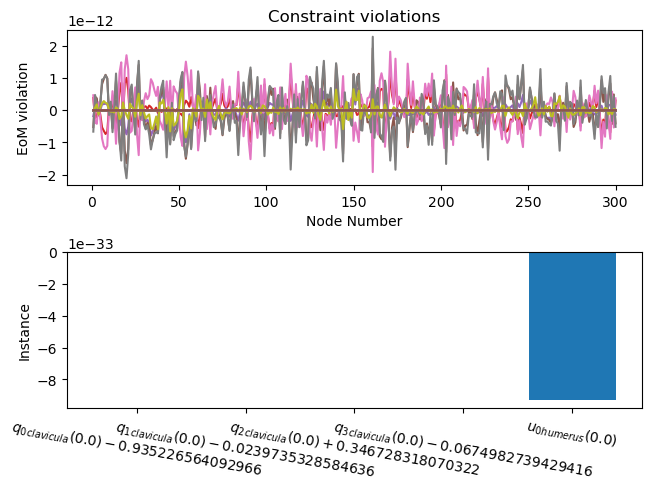

In [ ]:
_ = prob.plot_constraint_violations(solution)